In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

c:\Users\Khushbu.Kushvaha\Desktop\Kk\Langgraph_learn\my_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ----------------------
# 1) Create LTM store + seed memories (done before running graph)
# ----------------------

store = InMemoryStore()

user_id = 'u1'

# store user details as a single blob (simple to learn)
# you can also split into multiple records; thsi keeps it easy.

user_details = ('user', user_id, 'details')

store.put(user_details, 'profile_1', {'data': 'Name: khushbu'})
store.put(user_details, 'profile_2', {'data': 'profession: Ai Software Engineer'})
store.put(user_details, 'preferences_1', {'data': 'prefers concise answers'})
store.put(user_details, 'preferences_2', {'data': 'Likes examples in python'})
store.put(user_details, 'project_1', {'data': 'building MCP Serves (python base program)'})


In [3]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [4]:
import os
llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [5]:
# ------------- 
#  3) Build graph : START -> CHAT -> END (read-only LTM)
# ------------

def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    # Keep it dead simple for teaching.
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

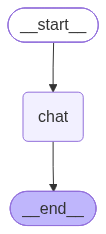

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [7]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain Importanct of LangGraph in Ai"}]},
    config,
)

print(result["messages"][-1].content)

Sure, **khushbu**!  

### Why LangGraph matters for AI (and your MCP Python server)

| Reason | What it gives you | Quick Python‑style illustration |
|--------|-------------------|---------------------------------|
| **Composable multi‑step flows** | Treat each tool/action as a node/edge – you can chain them arbitrarily, like a mini‑pipeline. | ```python\n# pseudo‑graph\nfrom langgraph import Graph\n\nbuilder = Graph()\nbuilder.add_node(\"search\", search_tool)          # node 1\nbuilder.add_node(\"summarize\", summarize_tool)   # node 2\nbuilder.add_edge(\"search\", \"summarize\")       # edge 1→2\nbuilder.set_entry_point(\"search\")\ngraph = builder.compile()\n``` |
| **Stateful coordination** | Nodes can read/write shared state, enabling context across steps (e.g., previous web results). | ```python\ndef search(state: State) -> State:\n    results = google_search(state.query)\n    return {\"search_results\": results}\n\ndef summarize(state: State) -> State:\n    state.summary = llm_

In [8]:
from IPython.display import Markdown, display
display(Markdown(result["messages"][-1].content))

Sure, **khushbu**!  

### Why LangGraph matters for AI (and your MCP Python server)

| Reason | What it gives you | Quick Python‑style illustration |
|--------|-------------------|---------------------------------|
| **Composable multi‑step flows** | Treat each tool/action as a node/edge – you can chain them arbitrarily, like a mini‑pipeline. | ```python\n# pseudo‑graph\nfrom langgraph import Graph\n\nbuilder = Graph()\nbuilder.add_node(\"search\", search_tool)          # node 1\nbuilder.add_node(\"summarize\", summarize_tool)   # node 2\nbuilder.add_edge(\"search\", \"summarize\")       # edge 1→2\nbuilder.set_entry_point(\"search\")\ngraph = builder.compile()\n``` |
| **Stateful coordination** | Nodes can read/write shared state, enabling context across steps (e.g., previous web results). | ```python\ndef search(state: State) -> State:\n    results = google_search(state.query)\n    return {\"search_results\": results}\n\ndef summarize(state: State) -> State:\n    state.summary = llm_summarize(state.search_results)\n    return state\n``` |
| **Dynamic routing** | Switch paths based on conditions (e.g., “if code needed → run‑code node; else → return plain answer”). | ```python\nif \"needs_code\" in state.meta:\n    return call_code_node(state)\nelse:\n    return final_answer_node(state)\n``` |
| **Reusability & modularity** | One node can be reused in many graphs (different MCPs). Keeps your server code DRY. | Define a reusable `fetch_api` node and drop it into any MCP workflow. |
| **Built‑in visualisation & debugging** | LangGraph can export a graph diagram and trace execution, great for monitoring MCP pipelines. | `graph.draw()` or `graph.compile().trace()` |

**Bottom line:** LangGraph gives you a *graph‑based execution engine* that turns a list of independent MCP tools into an interleaved, state‑aware workflow—perfect for AI agents that need to reason, call tools, and adapt on the fly.

---

### Quick Python snippet to glue an MCP server with LangGraph

```python
from langgraph import Graph, State
from typing import Dict

class StateDict:
    pass

class StateGraph(StateDict):
    query: str                # user input
    results: list = []        # results from external APIs
    summary: str = ""         # final answer
    step: int = 0             # which node we’re on

builder = Graph()

# Example end‑nodes that call your existing MCP functions
def search_node(state: StateGraph) -> StateGraph:
    state.results = call_mcp_search(state.query)      # your MCP call
    state.step += 1
    return state

def summarize_node(state: StateGraph) -> StateGraph:
    state.summary = summarize(state.results)          # use your summarizer
    state.step += 1
    return state

builder.add_node("search", search_node)
builder.add_node("summarize", summarize_node)
builder.set_entry_point("search")
graph = builder.compile()
```

Running `graph` will execute the search MCP, then the summarizer—all orchestrated by LangGraph without you manually wiring callbacks.

---

### 3 Follow‑up questions that might help you next

1. **How would you handle error recovery (e.g., a failed MCP call) inside a LangGraph workflow?**  
2. **Can you show a pattern for looping back to an earlier node when the initial answer isn’t satisfactory?**  
3. **What’s the best way to expose your compiled LangGraph as an API endpoint for other services?**  

Hope that gives you a clear picture—let me know which part you’d like to dive deeper into!

### Chatbot Creating New Memories

In [9]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore


In [10]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [11]:
# ----------------------------
# 2) LLM that decides what to remember (structured output)
# ----------------------------
extractor_llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)


In [12]:
## pydanctic model for structured output from LLM
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [13]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [14]:
# ----------------------------
# 3) Graph: START -> remember -> END
#    (Creates memories, but does NOT use them to answer)
# ----------------------------
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

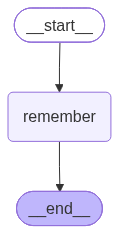

In [15]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [16]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Khushbu"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [20]:
res = graph.invoke({"messages": [{"role": "user", "content": "I am AI Engineer"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [18]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [21]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User's name is Khushbu.
User is an AI Engineer.
My favorite programming language is Python
User identifies as AI Engineer.


### Chatbot Creating New Memories(without Duplication)

In [22]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [23]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [25]:
# ----------------------------
# 2) LLMs
#    - memory_llm: extracts candidate memories + tells if each is NEW (no duplicate_of needed)
# ----------------------------

memory_llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [26]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW and should be stored. False if duplicate/already known.")

In [28]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

In [29]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)


In [30]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [31]:
def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]

    namespace = ("user", user_id, "details")

    # A) Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B) Latest user message
    last_text = state["messages"][-1]

    # C) LLM extracts memories + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": f"USER MESSAGE:\n{last_text}"},
        ]
    )

    # D) Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}

In [32]:
# ----------------------------
# 4) Build graph: START -> chat -> END
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

In [33]:
config = {"configurable": {"user_id": "u1"}}


In [34]:
r1 = graph.invoke({"messages": [{"role": "user", "content": "My name is Nitish"}]}, config)
print("Assistant:", r1["messages"][-1].content)

Assistant: Noted.


In [37]:

# Likely duplicate of the first memory -> is_new should be false -> saved=0
r2 = graph.invoke({"messages": [{"role": "user", "content": "I like Python for programming."}]}, config)
print("\nAssistant:", r2["messages"][-1].content)


Assistant: Noted.


In [38]:
for it in store.search(("user", "u1", "details")):
    print(it.value['data'])

My name is Nitish
I like Python for programming.


### Final Chat bot with creating and presonalizing answer

In [42]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [43]:
# ----------------------------
# 1) LTM store (START EMPTY)
# ----------------------------
store = InMemoryStore()

In [44]:
# ----------------------------
# 2) System prompt
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nitish...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""


In [45]:
# ----------------------------
# 3) Memory extraction LLM
# ----------------------------

memory_llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [46]:
class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory")
    is_new: bool = Field(description="True if new, false if duplicate")

    
class MemoryDecision(BaseModel):
    should_write: bool
    memories: List[MemoryItem] = Field(default_factory=list)

In [47]:
memory_extractor = memory_llm.with_structured_output(MemoryDecision)

In [48]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return should_write=false and an empty list.
"""

In [49]:
# ----------------------------
# 4) Node 1: remember
# ----------------------------
def remember_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    # existing memory
    items = store.search(ns)
    existing = "\n".join(it.value["data"] for it in items) if items else "(empty)"

    # last user message
    last_msg = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            {"role": "user", "content": last_msg},
        ]
    )

    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(ns, str(uuid.uuid4()), {"data": mem.text})

    return {}  # no message change

In [50]:
# ----------------------------
# 5) Node 2: chat
# ----------------------------

chat_llm = ChatOpenAI(
    model="nvidia/nemotron-3-nano-30b-a3b:free",   # or any OpenRouter model
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [51]:
def chat_node(state: MessagesState, config: RunnableConfig, *, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    ns = ("user", user_id, "details")

    items = store.search(ns)
    user_details = "\n".join(it.value["data"] for it in items) if items else ""

    system_msg = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(
            user_details_content=user_details or "(empty)"
        )
    )

    response = chat_llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

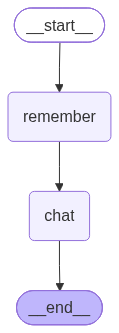

In [52]:
# ----------------------------
# 6) Graph
# ----------------------------
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_node)
builder.add_node("chat", chat_node)

builder.add_edge(START, "remember")
builder.add_edge("remember", "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [53]:
# ----------------------------
# 7) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

In [54]:
result = graph.invoke({"messages": [{"role": "user", "content": "Hi, my name is Khushbu"}]}, config)
result['messages'][-1].content

"Hi Khushbu! 👋 It's great to meet you. How can I help you today? If you'd like to share what you're working on or any particular project you have in mind, just let me know—I'd love to dive in with you!  \n\n**Here are three quick questions to help me understand what you need:**  \n\n1. Are you currently building any Python‑based MCP integrations or other automation tools?  \n2. Is there a specific problem you're trying to solve in your brokerage environment that you’d like help troubleshooting?  \n3. What tools or frameworks are you currently using or considering for your projects?  \n\nLooking forward to hearing more about what you're working on! 🚀"

In [55]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Name: Khushbu


In [56]:
result = graph.invoke({"messages": [{"role": "user", "content": "I am Ai Engineer"}]}, config)
print(result['messages'][-1].content)

Sure, Khushbu! 👋 It's great to meet an AI Engineer like you. How’s your current project shaping up? 

Would you like to share details about the specific AI tools or frameworks you’re working with?  

And finally, is there any particular challenge or learning goal you’re focusing on right now?


In [57]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Name: Khushbu
I am AI Engineer


In [58]:
result = graph.invoke({"messages": [{"role": "user", "content": "Explain GenAI simply"}]}, config)
print(result['messages'][-1].content)

Hey Khushbu! 😊  

**Generative AI (GenAI) in a nutshell**

Think of GenAI as a super‑smart “creative assistant” that can **generate** new content—text, images, music, code, even videos—by learning patterns from huge amounts of existing data. Instead of just retrieving or analyzing information (like a regular search engine or a traditional AI model), it **creates** something fresh that’s often indistinguishable from human‑made work.

- **How it works:**  
  1. **Training:** It’s fed massive datasets (e.g., books, images, code repositories).  
  2. **Learning patterns:** It figures out the underlying grammar, style, structures, and relationships.  
  3. **Generation:** When you give it a prompt, it predicts the most likely continuation—whether that’s a paragraph, a picture, a melody, or a line of code.

- **What it can do:**  
  * Write emails, articles, or even poetry.  
  * Produce realistic images or artwork from textual descriptions.  
  * Draft code snippets, suggest complete functi

In [60]:
from IPython.display import Markdown, display
display(Markdown(result["messages"][-1].content))

Hey Khushbu! 😊  

**Generative AI (GenAI) in a nutshell**

Think of GenAI as a super‑smart “creative assistant” that can **generate** new content—text, images, music, code, even videos—by learning patterns from huge amounts of existing data. Instead of just retrieving or analyzing information (like a regular search engine or a traditional AI model), it **creates** something fresh that’s often indistinguishable from human‑made work.

- **How it works:**  
  1. **Training:** It’s fed massive datasets (e.g., books, images, code repositories).  
  2. **Learning patterns:** It figures out the underlying grammar, style, structures, and relationships.  
  3. **Generation:** When you give it a prompt, it predicts the most likely continuation—whether that’s a paragraph, a picture, a melody, or a line of code.

- **What it can do:**  
  * Write emails, articles, or even poetry.  
  * Produce realistic images or artwork from textual descriptions.  
  * Draft code snippets, suggest complete functions, or help with debugging.  
  * Compose music or generate synthetic voices.  

- **Why it matters for you as an AI Engineer:**  
  * It lets you **automate repetitive creative tasks**, freeing up time for higher‑level design.  
  * You can build **custom pipelines** that generate domain‑specific outputs (e.g., synthetic medical images, tailored code snippets for embedded systems).  
  * It opens doors to **rapid prototyping**—test ideas by simply prompting the model, then iterate without writing everything from scratch.

In short, GenAI is the “creative engine” behind many of the AI‑powered tools you might be exploring in the MCP server Python project or other AI‑centric initiatives.

---

**Next steps? Here are three questions that could help you dive deeper based on what we just covered:**

1. **Which specific generative models (e.g., GPT‑4, Stable Diffusion, Midjourney, CodeLlama) are you currently experimenting with in your projects, and what are the main challenges you’ve encountered?**  
2. **Are you interested in building your own command‑line or API interface for a GenAI model within the MCP server, perhaps to let your team generate code or documentation on demand?**  
3. **What domains or data types (text, images, audio, code) are you most eager to generate content for, and how could customizing a GenAI pipeline boost your workflow?**  

Let me know which of these sparks your curiosity, or feel free to share any other project details you’d like advice on! 🚀

In [59]:
for it in store.search(("user", "u1", "details")):
    print(it.value["data"])

Name: Khushbu
I am AI Engineer
